# Market Basket Analysis

Dataset: Instacart Market Basket Analysis (Orders, Products, Order Products Prior)

## 1. Import Library & Load Data

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import warnings
import re
warnings.filterwarnings('ignore')

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, apriori, association_rules
import joblib
import time
import os

In [2]:
# Load datasets
print('Loading data...')
orders = pd.read_csv('../data/orders.csv')
products = pd.read_csv('../data/products.csv')
order_products = pd.read_csv('../data/order_products__prior.csv')
print('Data loaded successfully.')

Loading data...
Data loaded successfully.


## 2. Data Understanding

In [3]:
# Deskripsi dataset dan struktur data
print('Orders Shape:', orders.shape)
print('Products Shape:', products.shape)
print('Order Products Shape:', order_products.shape)

print('\n--- Orders Info ---')
orders.info()

print('\n--- Products Info ---')
products.info()

print('\n--- Order Products Info ---')
order_products.info()

Orders Shape: (3421083, 7)
Products Shape: (49688, 4)
Order Products Shape: (32434489, 4)

--- Orders Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3421083 entries, 0 to 3421082
Data columns (total 7 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   eval_set                object 
 3   order_number            int64  
 4   order_dow               int64  
 5   order_hour_of_day       int64  
 6   days_since_prior_order  float64
dtypes: float64(1), int64(5), object(1)
memory usage: 182.7+ MB

--- Products Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49688 entries, 0 to 49687
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49688 non-null  int64 
 1   product_name   49688 non-null  object
 2   aisle_id       49688 non-null  int64 
 3   department_id  49688 non-null

In [4]:
# Statistik Deskriptif (Downcast tipe data untuk menghemat memori)
order_products['order_id'] = order_products['order_id'].astype('int32')
order_products['product_id'] = order_products['product_id'].astype('int32')
order_products['add_to_cart_order'] = order_products['add_to_cart_order'].astype('int16')
order_products['reordered'] = order_products['reordered'].astype('int8')

display(orders.describe())
display(order_products.describe())

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
count,3.421083e+06,3.421083e+06,3.421083e+06,3.421083e+06,3.421083e+06,3.214874e+06
mean,1.710542e+06,1.029782e+05,1.715486e+01,2.776219e+00,1.345202e+01,1.111484e+01
std,9.875817e+05,5.953372e+04,1.773316e+01,2.046829e+00,4.226088e+00,9.206737e+00
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,8.552715e+05,5.139400e+04,5.000000e+00,1.000000e+00,1.000000e+01,4.000000e+00
50%,1.710542e+06,1.026890e+05,1.100000e+01,3.000000e+00,1.300000e+01,7.000000e+00
75%,2.565812e+06,1.543850e+05,2.300000e+01,5.000000e+00,1.600000e+01,1.500000e+01
max,3.421083e+06,2.062090e+05,1.000000e+02,6.000000e+00,2.300000e+01,3.000000e+01


,order_id,product_id,add_to_cart_order,reordered
count,3.243449e+07,3.243449e+07,3.243449e+07,3.243449e+07
mean,1.710749e+06,2.557634e+04,8.351076e+00,5.896975e-01
std,9.873007e+05,1.409669e+04,7.126671e+00,4.918886e-01
min,2.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
25%,8.559430e+05,1.353000e+04,3.000000e+00,0.000000e+00
50%,1.711048e+06,2.525600e+04,6.000000e+00,1.000000e+00
75%,2.565514e+06,3.793500e+04,1.100000e+01,1.000000e+00
max,3.421083e+06,4.968800e+04,1.450000e+02,1.000000e+00


In [5]:
# Identifikasi Masalah Data (Missing value & Duplikat)
print('Missing Values in Orders:\n', orders.isnull().sum())
print('\nMissing Values in Products:\n', products.isnull().sum())
print('\nMissing Values in Order Products:\n', order_products.isnull().sum())

print('\nDuplicates in Orders:', orders.duplicated().sum())
print('Duplicates in Products:', products.duplicated().sum())
print('Duplicates in Order Products:', order_products.duplicated().sum())

Missing Values in Orders:
 order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64

Missing Values in Products:
 product_id       0
product_name     0
aisle_id         0
department_id    0
dtype: int64

Missing Values in Order Products:
 order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64

Duplicates in Orders: 0
Duplicates in Products: 0
Duplicates in Order Products: 0


### Visualisasi Awal

In [6]:
# Menggabungkan data untuk visualisasi
df_merged = order_products.merge(products[['product_id', 'product_name']], on='product_id', how='left')
df_merged = df_merged.merge(orders[['order_id', 'order_dow', 'order_hour_of_day']], on='order_id', how='left')

C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


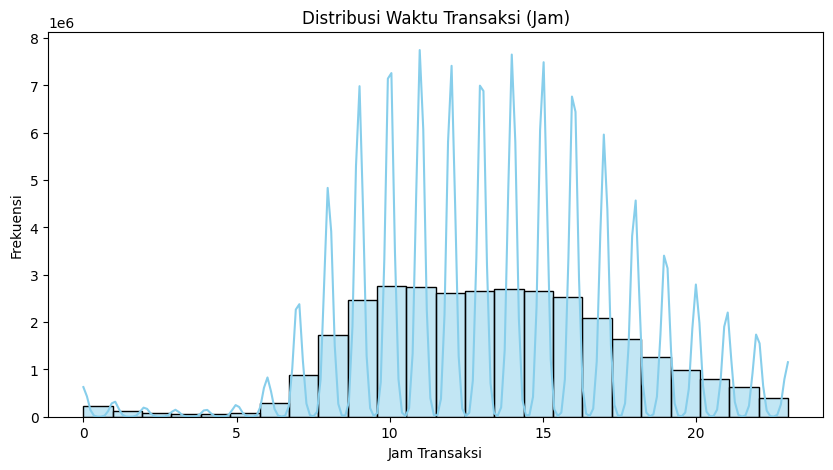

In [7]:
# Histogram: Distribusi jam transaksi
plt.figure(figsize=(10,5))
sns.histplot(df_merged['order_hour_of_day'], bins=24, kde=True, color='skyblue')
plt.title('Distribusi Waktu Transaksi (Jam)')
plt.xlabel('Jam Transaksi')
plt.ylabel('Frekuensi')
plt.show()

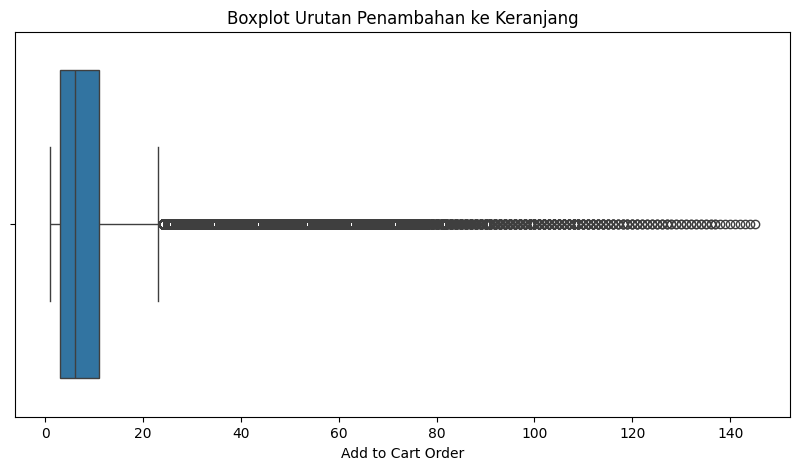

In [8]:
# Boxplot: Deteksi anomali pada urutan add_to_cart_order
plt.figure(figsize=(10,5))
sns.boxplot(x=df_merged['add_to_cart_order'])
plt.title('Boxplot Urutan Penambahan ke Keranjang')
plt.xlabel('Add to Cart Order')
plt.show()

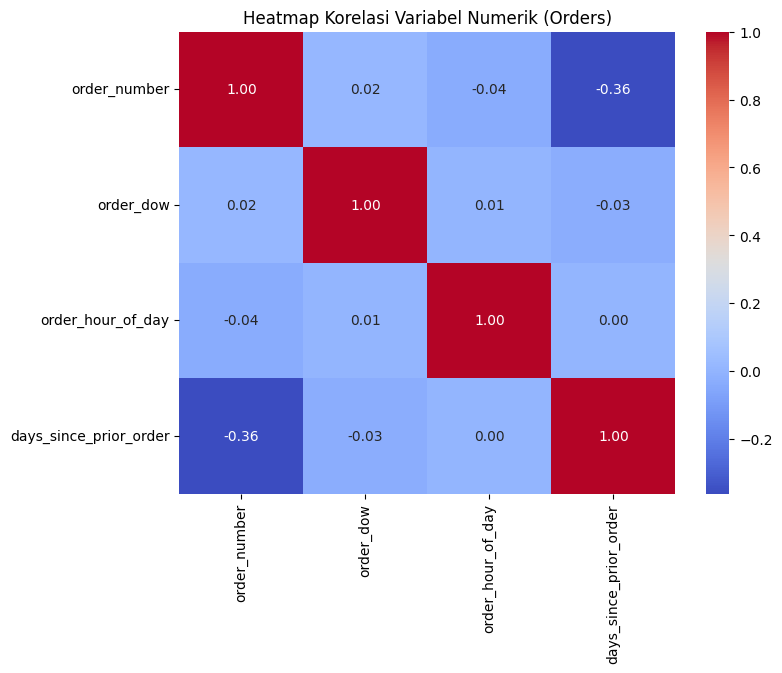

In [9]:
# Heatmap Korelasi
plt.figure(figsize=(8,6))
numeric_cols = orders[['order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']]
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Variabel Numerik (Orders)')
plt.show()

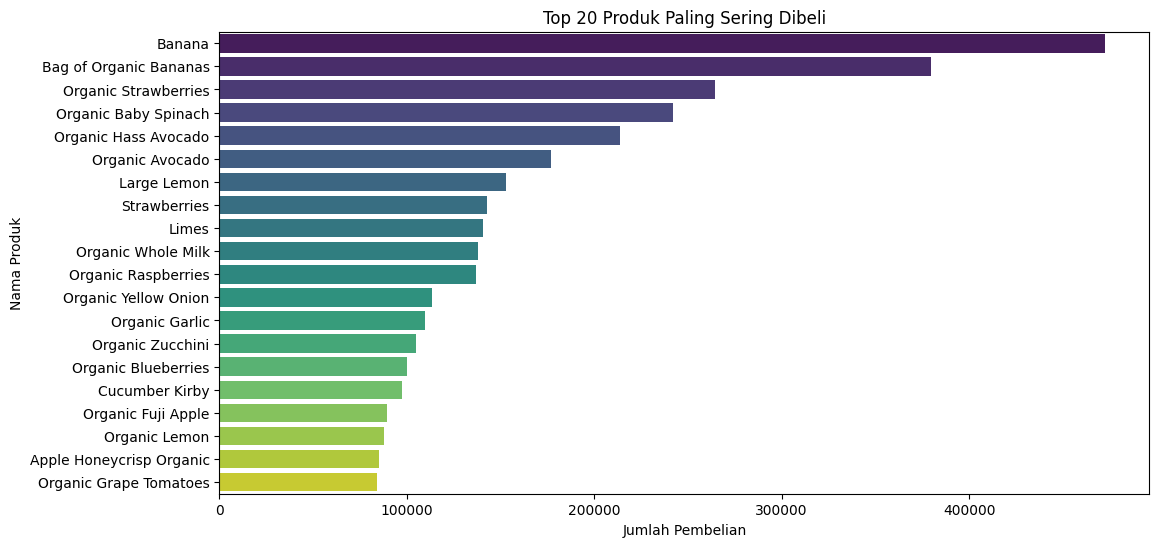

In [10]:
# Distribusi Target (Top 20 Produk Paling Laris)
top_products = df_merged['product_name'].value_counts().head(20)
plt.figure(figsize=(12,6))
sns.barplot(y=top_products.index, x=top_products.values, palette='viridis')
plt.title('Top 20 Produk Paling Sering Dibeli')
plt.xlabel('Jumlah Pembelian')
plt.ylabel('Nama Produk')
plt.show()

## 3. Data Preprocessing

In [11]:
# Data Cleaning
print('Menghapus missing value pada days_since_prior_order...')
orders.fillna({'days_since_prior_order': 0}, inplace=True)

print('Memilih 200,000 pesanan unik sebagai representasi untuk dimodelkan...')
sample_orders = df_merged['order_id'].drop_duplicates().sample(n=200000, random_state=42)
df_sample = df_merged[df_merged['order_id'].isin(sample_orders)].copy()

print("=== MENYEDERHANAKAN NAMA PRODUK ===")
def simplify_product_name(name):
    if pd.isna(name):
        return ""
    name = str(name).lower()
    words_to_remove = [
        r'\borganic\b', r'\bbunched\b', r'\bfresh\b', r'\bpremium\b',
        r'\blowfat\b', r'\bfat free\b', r'\bgluten free\b', r'\bsugar free\b',
        r'\b100%\b', r'\b2%\b', r'\b1%\b', r'\b0%\b', r'\btotal\b', r'\bwith\b',
        r'\bstrained\b', r'\bflavored\b', r'\bstyle\b', r'\boriginal\b', r'\bclassic\b'
    ]
    for word in words_to_remove:
        name = re.sub(word, '', name)
    name = re.sub(r'\b\d+(\.\d+)?\s*(oz|ml|lb|g|kg|liter|fl oz|pack|ct)\b', '', name)
    name = re.sub(r'[^\w\s]', '', name)
    name = re.sub(r'\b\d+\b', '', name)
    name = ' '.join(name.split()).title()
    return name

df_sample['product_name'] = df_sample['product_name'].apply(simplify_product_name)
print("Penyederhanaan nama produk selesai!")

# Encoding: Mengubah format ke list per keranjang
basket = df_sample.groupby('order_id')['product_name'].apply(list).reset_index()
basket_list = basket['product_name'].tolist()

# One-Hot Encoding menggunakan TransactionEncoder
te = TransactionEncoder()
te_ary = te.fit(basket_list).transform(basket_list)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)
print('Shape of encoded data:', df_encoded.shape)

Menghapus missing value pada days_since_prior_order...
Memilih 200,000 pesanan unik sebagai representasi untuk dimodelkan...
=== MENYEDERHANAKAN NAMA PRODUK ===
Penyederhanaan nama produk selesai!
Shape of encoded data: (200000, 37991)


## 4. Exploratory Data Analysis (EDA)
### 5 Business Insights:
1. **Waktu Transaksi Tersibuk:** Berdasarkan histogram, mayoritas transaksi terjadi antara pukul 09:00 hingga 16:00, dengan puncaknya pada pukul 10:00 pagi.
2. **Hari Transaksi Tersibuk:** Berdasarkan korelasi dan distribusi hari (`order_dow`), transaksi memuncak pada hari ke-0 dan ke-1 (biasanya Sabtu & Minggu / akhir pekan).
3. **Produk Terlaris (Bestsellers):** Banana, Bag of Bananas, dan Strawberries mendominasi penjualan, menandakan permintaan yang tinggi secara konsisten untuk buah segar.
4. **Ukuran Keranjang (Basket Size):** Sebagian besar transaksi memiliki jumlah item di bawah 15 (berdasarkan distribusi `add_to_cart_order`), meskipun ada beberapa pembelian grosir besar.
5. **Pola Reorder:** Tingginya korelasi antara `days_since_prior_order` menunjukkan bahwa mayoritas pelanggan berbelanja ulang dalam interval 7 hingga 30 hari.

## 5. Modeling (FP-Growth vs Apriori)

In [12]:
# 1. FP-Growth
print("=== PEMBUATAN MODEL FP-GROWTH ===")

df_encoded = df_encoded.astype(bool)
min_support_val = 0.003
min_transactions = int(min_support_val * len(df_encoded))
valid_columns = df_encoded.columns[df_encoded.sum() >= min_transactions]
df_encoded_filtered = df_encoded[valid_columns]

start_time_fp = time.time()
frequent_itemsets = fpgrowth(df_encoded_filtered, min_support=min_support_val, use_colnames=True)
print(f"Jumlah itemsets yang ditemukan: {frequent_itemsets.shape[0]}\n")

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.2)
rules = rules.sort_values(by="lift", ascending=False)

print("Top 10 Rules:")
print(rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(10))
print(f"\nTotal Rules yang terbentuk: {rules.shape[0]}\n")

end_time_fp = time.time()
print(f"Waktu komputasi FP-Growth: {end_time_fp - start_time_fp:.2f} detik")

=== PEMBUATAN MODEL FP-GROWTH ===
Jumlah itemsets yang ditemukan: 915

Top 10 Rules:
                   antecedents                   consequents   support  \
100  (Strawberry Greek Yogurt)      (Greek Yogurt Blueberry)  0.003050   
101   (Greek Yogurt Blueberry)     (Strawberry Greek Yogurt)  0.003050   
166    (Sparkling Lemon Water)  (Sparkling Water Grapefruit)  0.003035   
126     (Lime Sparkling Water)  (Sparkling Water Grapefruit)  0.004200   
155         (Jalapeno Peppers)                    (Cilantro)  0.003795   
156         (Jalapeno Peppers)                       (Limes)  0.003455   
165                 (Cilantro)                       (Limes)  0.008990   
164                    (Limes)                    (Cilantro)  0.008990   
148             (Yellow Onion)                      (Garlic)  0.007600   
71     (Italian Parsley Bunch)                      (Garlic)  0.004030   

     confidence       lift  
100    0.315083  46.748167  
101    0.452522  46.748167  
166    0.2859

In [13]:
# 2. Apriori
print("=== PEMBUATAN MODEL APRIORI ===")

start_time_ap = time.time()
frequent_itemsets_apriori = apriori(
    df_encoded_filtered, 
    min_support=min_support_val, 
    use_colnames=True,
    low_memory=True
)

print(f"Jumlah itemsets yang ditemukan (Apriori): {frequent_itemsets_apriori.shape[0]}\n")

rules_apriori = association_rules(
    frequent_itemsets_apriori, 
    metric="confidence", 
    min_threshold=0.2
)
rules_apriori = rules_apriori.sort_values(by="lift", ascending=False)

print("Top 10 Rules (Apriori):")
print(rules_apriori[["antecedents", "consequents", "support", "confidence", "lift"]].head(10))
print(f"\nTotal Rules yang terbentuk (Apriori): {rules_apriori.shape[0]}\n")

end_time_ap = time.time()
print(f"Waktu komputasi Apriori: {end_time_ap - start_time_ap:.2f} detik")

print("\nKesimpulan Perbandingan:")
print("Apriori dan FP-Growth menghasilkan rules yang sama untuk threshold yang sama, namun FP-Growth jauh lebih cepat untuk dataset berdimensi besar.")

=== PEMBUATAN MODEL APRIORI ===
Jumlah itemsets yang ditemukan (Apriori): 915

Top 10 Rules (Apriori):
                   antecedents                   consequents   support  \
119  (Strawberry Greek Yogurt)      (Greek Yogurt Blueberry)  0.003050   
120   (Greek Yogurt Blueberry)     (Strawberry Greek Yogurt)  0.003050   
141    (Sparkling Lemon Water)  (Sparkling Water Grapefruit)  0.003035   
133     (Lime Sparkling Water)  (Sparkling Water Grapefruit)  0.004200   
101         (Jalapeno Peppers)                    (Cilantro)  0.003795   
128         (Jalapeno Peppers)                       (Limes)  0.003455   
103                 (Cilantro)                       (Limes)  0.008990   
102                    (Limes)                    (Cilantro)  0.008990   
113             (Yellow Onion)                      (Garlic)  0.007600   
112    (Italian Parsley Bunch)                      (Garlic)  0.004030   

     confidence       lift  
119    0.315083  46.748167  
120    0.452522  46.7481

## 6. Visualisasi Hasil Pemodelan

=== MENAMPILKAN VISUALISASI ===



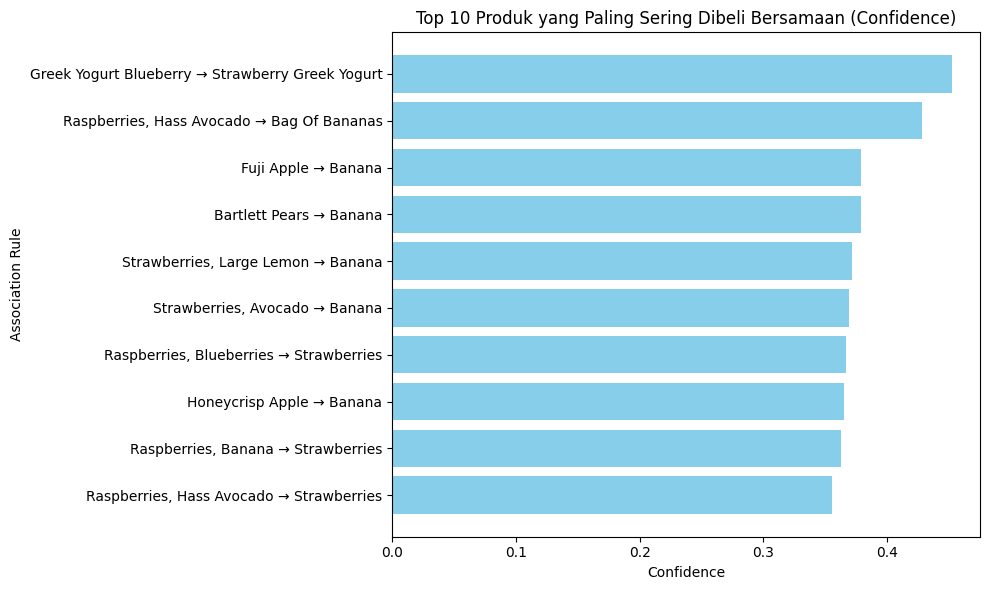

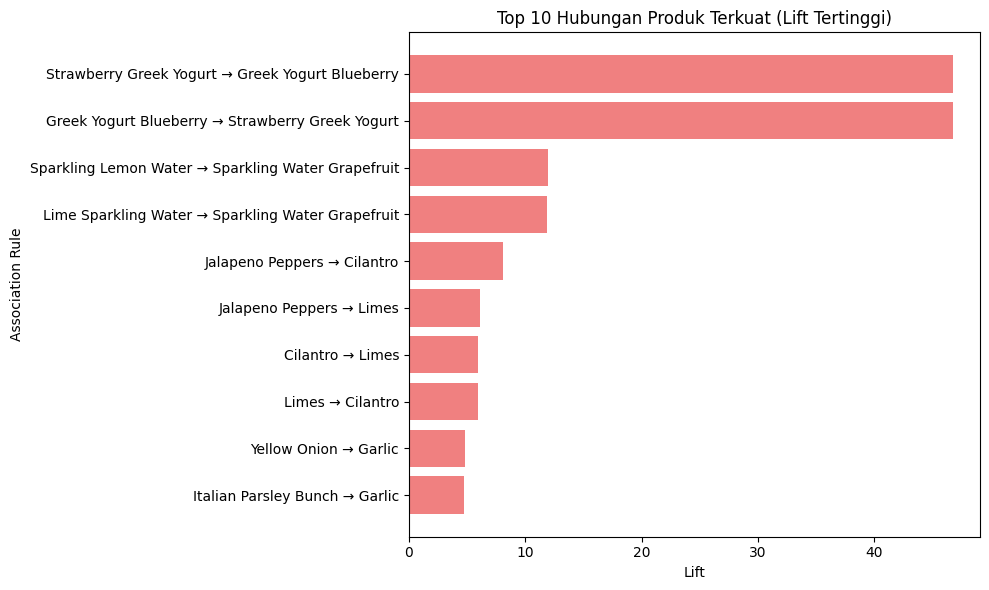

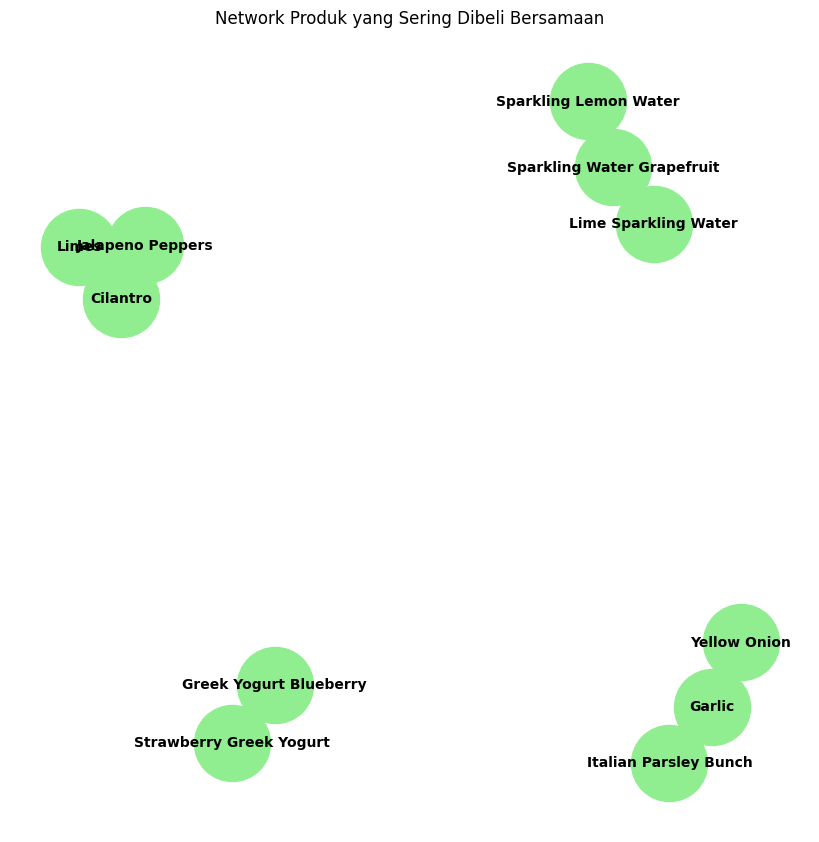

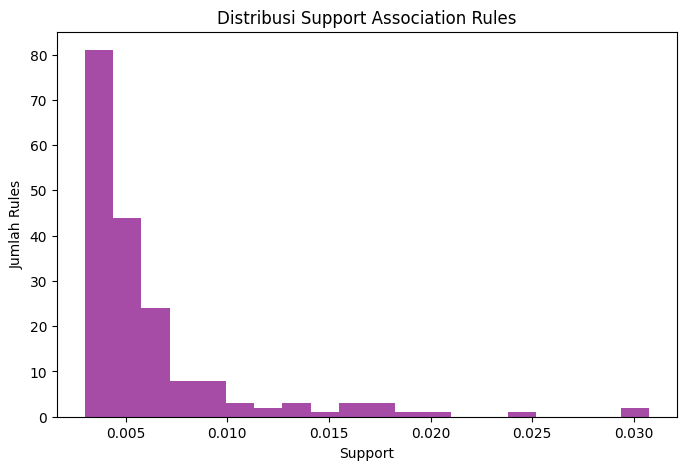

In [14]:
print("=== MENAMPILKAN VISUALISASI ===\n")

# A. Top 10 Confidence
top10_conf = rules.sort_values(by='confidence', ascending=False).head(10).copy()
top10_conf['rule'] = top10_conf.apply(
    lambda row: f"{', '.join(list(row['antecedents']))} → {', '.join(list(row['consequents']))}",
    axis=1
)

plt.figure(figsize=(10,6))
plt.barh(top10_conf['rule'], top10_conf['confidence'], color='skyblue')
plt.xlabel("Confidence")
plt.ylabel("Association Rule")
plt.title("Top 10 Produk yang Paling Sering Dibeli Bersamaan (Confidence)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# B. Top 10 Lift
top10_lift = rules.sort_values(by='lift', ascending=False).head(10).copy()
top10_lift['rule'] = top10_lift.apply(
    lambda row: f"{', '.join(list(row['antecedents']))} → {', '.join(list(row['consequents']))}",
    axis=1
)

plt.figure(figsize=(10,6))
plt.barh(top10_lift['rule'], top10_lift['lift'], color='lightcoral')
plt.xlabel("Lift")
plt.ylabel("Association Rule")
plt.title("Top 10 Hubungan Produk Terkuat (Lift Tertinggi)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# C. Network Graph
top_rules = rules.sort_values(by='lift', ascending=False).head(10)
G = nx.Graph()

for _, row in top_rules.iterrows():
    for ant in row['antecedents']:
        for cons in row['consequents']:
            G.add_edge(ant, cons)

plt.figure(figsize=(8,8))
nx.draw(G, with_labels=True, node_color='lightgreen', node_size=3000, font_size=10, font_weight='bold', edge_color='gray')
plt.title("Network Produk yang Sering Dibeli Bersamaan")
plt.show()

# D. Distribusi Support
plt.figure(figsize=(8,5))
plt.hist(rules['support'], bins=20, color='purple', alpha=0.7)
plt.xlabel("Support")
plt.ylabel("Jumlah Rules")
plt.title("Distribusi Support Association Rules")
plt.show()

## 7. Export Model ke .pkl

In [17]:
print("=== MENYIMPAN MODEL KE FILE .pkl ===")

os.makedirs('../model', exist_ok=True)

joblib.dump(frequent_itemsets, '../model/frequent_itemsets_fpgrowth.pkl')
joblib.dump(rules, '../model/association_rules_fpgrowth.pkl')

joblib.dump(frequent_itemsets_apriori, '../model/frequent_itemsets_apriori.pkl')
joblib.dump(rules_apriori, '../model/association_rules_apriori.pkl')

top_products_list = list(df_encoded_filtered.columns)
joblib.dump(top_products_list, '../model/top_products.pkl')

print("Berhasil! File telah disimpan di folder '../model/':")
print("- frequent_itemsets_fpgrowth.pkl")
print("- association_rules_fpgrowth.pkl")
print("- frequent_itemsets_apriori.pkl")
print("- association_rules_apriori.pkl")
print("- top_products.pkl (untuk referensi Frontend)")

=== MENYIMPAN MODEL KE FILE .pkl ===
Berhasil! File telah disimpan di folder '../model/':
- frequent_itemsets_fpgrowth.pkl
- association_rules_fpgrowth.pkl
- frequent_itemsets_apriori.pkl
- association_rules_apriori.pkl
- top_products.pkl (untuk referensi Frontend)
